# 02 EDA

Explore distributions, relationships, anomalies, and early business metrics before building SQL models or Power BI reports.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns


RAW_DATA_DIR = Path("../data/raw")

# Loading the 9 Olist datasets
orders = pd.read_csv(RAW_DATA_DIR / "olist_orders_dataset.csv")
customers = pd.read_csv(RAW_DATA_DIR / "olist_customers_dataset.csv")
geolocation = pd.read_csv(RAW_DATA_DIR / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(RAW_DATA_DIR / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(RAW_DATA_DIR / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(RAW_DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW_DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_DATA_DIR / "olist_sellers_dataset.csv")
categories = pd.read_csv(RAW_DATA_DIR / "product_category_name_translation.csv")

tables = {
    "orders": orders,
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "categories": categories,
}

#### Converting date columns to datetime format


In [2]:
date_columns = {}

for table_name, table in tables.items():
    cols = [
        col for col in table.columns 
        if any(word in col.lower() for word in ["date", "time", "timestamp", "created_at", "updated_at", "delivered_at", "approved_at"])
    ]
    date_columns[table_name] = cols
    
    
date_columns
    

{'orders': ['order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date'],
 'customers': [],
 'geolocation': [],
 'order_items': ['shipping_limit_date'],
 'order_payments': [],
 'order_reviews': ['review_creation_date', 'review_answer_timestamp'],
 'products': [],
 'sellers': [],
 'categories': []}

In [3]:
# Mapping date columns to their respective tables
orders_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

order_items_date_cols = [
    "shipping_limit_date",
]

reviews_date_cols = [
    "review_creation_date",
    "review_answer_timestamp",
]

In [4]:
# converting those columns to datetime format

for col in orders_date_cols:
    tables["orders"][col] = pd.to_datetime(tables["orders"][col], errors="coerce")

for col in order_items_date_cols:
    tables["order_items"][col] = pd.to_datetime(tables["order_items"][col], errors="coerce")

for col in reviews_date_cols:
    tables["order_reviews"][col] = pd.to_datetime(tables["order_reviews"][col], errors="coerce") 

In [5]:
# checking results

print(tables["orders"][orders_date_cols].dtypes)
print(tables["order_items"][order_items_date_cols].dtypes)
print(tables["order_reviews"][reviews_date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
shipping_limit_date    datetime64[ns]
dtype: object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [6]:
# Creating date-derived fields for order-level EDA

orders["order_purchase_date"] = orders["order_purchase_timestamp"].dt.date
orders["order_purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["order_purchase_dayofweek"] = orders["order_purchase_timestamp"].dt.day_name()

In [7]:
print("order date range:", orders["order_purchase_timestamp"].agg(["min", "max"]))


order date range: min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[ns]


In [8]:
# monthly orders 

monthly_orders = (
    orders
    .groupby("order_purchase_month")
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
    )

monthly_orders


,order_purchase_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


### visualizing monthly orders over time

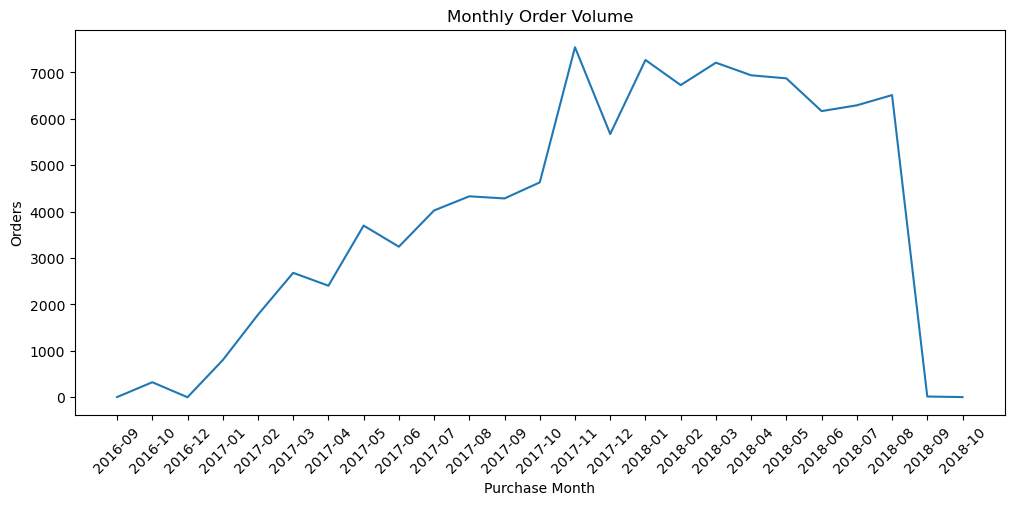

In [9]:
monthly_orders["order_purchase_month"] = monthly_orders["order_purchase_month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["order_purchase_month"], monthly_orders["order_count"])
plt.xticks(rotation=45)
plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Orders")
plt.show()

#### Order Status Distribution

Before calculating revenue or delivery metrics, we need to understand order status. Delivered orders should be the main base for completed-sales analysis, while canceled/unavailable orders should be tracked separately.

In [10]:
order_status_counts = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

order_status_counts["percentage"] = (
    order_status_counts["order_count"] / order_status_counts["order_count"].sum() * 100
).round(2)

order_status_counts

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


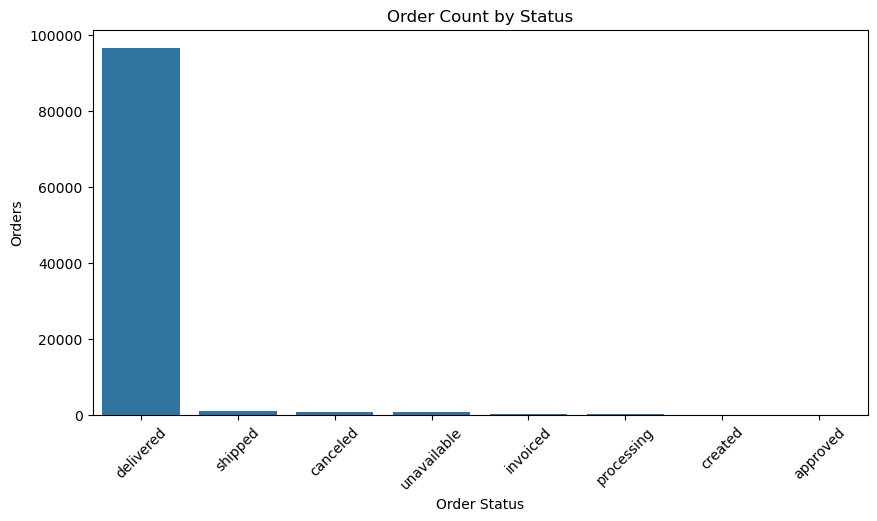

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=order_status_counts,
    x="order_status",
    y="order_count"
)
plt.title("Order Count by Status")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

#### Observation

Most orders are delivered, so completed-sales analysis should mainly use delivered orders. Canceled and unavailable orders should be excluded from delivery-time analysis but kept as operational quality indicators.

In [12]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()
delivered_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_date,order_purchase_year,order_purchase_month,order_purchase_dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017,2017-10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018,2018-07,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018,2018-08,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-18,2017,2017-11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-13,2018,2018-02,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,2017-03-09,2017,2017-03,Thursday
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018-02-06,2018,2018-02,Tuesday
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017-08-27,2017,2017-08,Sunday
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018-01-08,2018,2018-01,Monday


#### Monthly Revenue and AOV

For completed-sales KPIs, we use delivered orders as the base and calculate revenue from `order_items.price`. Since `order_items` is item-line level, joining it to delivered orders changes the grain from one row per order to one row per order item.

In [13]:
order_items_order_level = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        nb_items=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_shipping_cost=("freight_value", "sum")
    )
)

delivered_orders_items = delivered_orders.merge(
    order_items_order_level,
    on="order_id",
    how="left"
)

monthly_kpis = (
    delivered_orders_items
    .groupby("order_purchase_month", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        revenue=("total_price", "sum"),
        shipping_revenue=("total_shipping_cost", "sum"),
        items_sold=("nb_items", "sum")
    )
)

monthly_kpis["aov"] = monthly_kpis["revenue"] / monthly_kpis["delivered_orders"]

monthly_kpis 


,order_purchase_month,delivered_orders,revenue,shipping_revenue,items_sold,aov
0,2016-09,1,134.97,8.49,3,134.970000
1,2016-10,265,40325.11,6165.55,313,152.170226
2,2016-12,1,10.90,8.72,1,10.900000
3,2017-01,750,111798.36,15684.01,913,149.064480
4,2017-02,1653,234223.40,37015.92,1858,141.695947
5,2017-03,2546,359198.85,55132.10,2897,141.083602
6,2017-04,2303,340669.68,50142.72,2569,147.924307
7,2017-05,3546,489338.25,77513.15,4004,137.997250
8,2017-06,3135,421923.37,68127.00,3489,134.584807
9,2017-07,3872,481604.52,84694.56,4416,124.381333


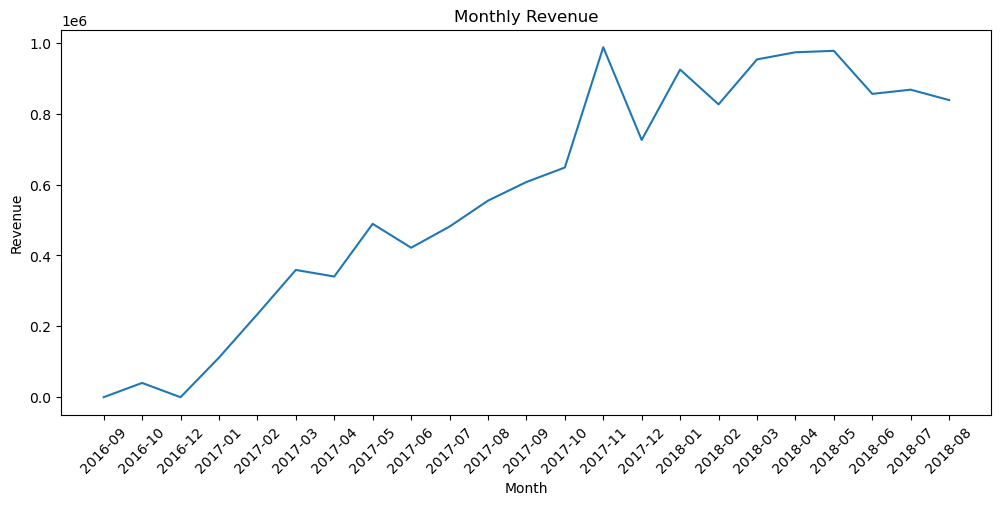

In [14]:
# visualizing monthly revenue

plt.figure(figsize=(12, 5))
plt.plot(monthly_kpis["order_purchase_month"].astype(str), monthly_kpis["revenue"])
plt.xticks(rotation=45) 
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

#### Observation

Revenue is calculated from `order_items.price`, because this table contains item-level product prices. Joining delivered orders to order items changes the grain to item-line level, which is appropriate for summing revenue and freight. Order counts should still be calculated from the order table or with `nunique(order_id)` to avoid counting multi-item orders multiple times.

#### Product and Category Performance

After understanding monthly order and revenue trends, we analyze which product categories contribute most to sales. This analysis uses the item-line grain from `order_items`, joined to delivered orders so that only completed sales are included.

In [17]:
delivered_order_items = (
    delivered_orders[["order_id", "order_purchase_month"]]
    .merge(order_items, on="order_id", how="inner")
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(categories, on="product_category_name", how="left")
)

delivered_order_items["category_name"] = (
    delivered_order_items["product_category_name_english"]
    .fillna(delivered_order_items["product_category_name"])
)

delivered_order_items.head()

,order_id,order_purchase_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,category_name
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,stationery,stationery


In [21]:
category_performance = (
    delivered_order_items
    .groupby("category_name", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        avg_item_price=("price", "mean")
    ).round(2)
    
)

category_performance["gross_order_item_value"] = (
    category_performance["product_revenue"] + category_performance["freight_value"]
).round(2)

category_performance = category_performance.sort_values(
    "product_revenue",
    ascending=False
)

category_performance.head(10)

,category_name,orders,items_sold,product_revenue,freight_value,avg_item_price,gross_order_item_value
43,health_beauty,8647,9465,1233131.72,178957.81,130.28,1412089.53
72,watches_gifts,5495,5859,1166176.98,98156.14,199.04,1264333.12
7,bed_bath_table,9272,10953,1023434.76,201774.50,93.44,1225209.26
67,sports_leisure,7530,8431,954852.55,163404.36,113.25,1118256.91
15,computers_accessories,6530,7644,888724.61,143999.16,116.26,1032723.77
39,furniture_decor,6307,8160,711927.69,168402.23,87.25,880329.92
49,housewares,5743,6795,615628.69,142763.56,90.60,758392.25
20,cool_stuff,3559,3718,610204.10,81476.79,164.12,691680.89
5,auto,3810,4140,578966.65,90488.10,139.85,669454.75
71,toys,3804,4030,471286.48,75774.58,116.94,547061.06


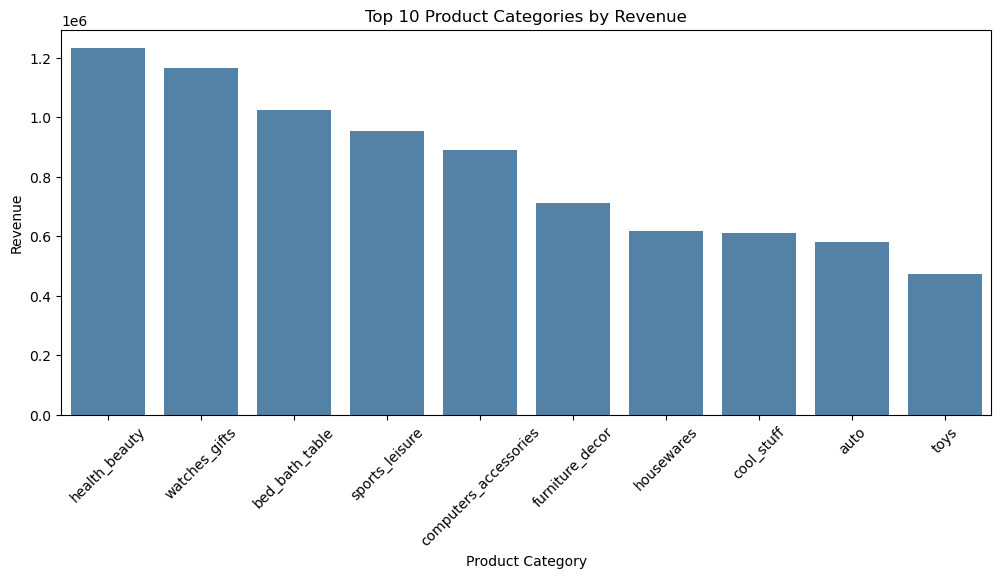

In [26]:
top_10_categories = category_performance.head(10)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_10_categories,
    x="category_name",
    y="product_revenue",
    color = "steelblue"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


In [29]:
# visualizing top 10 categories by orders

category_performance_by_orders = category_performance.sort_values(
    "orders",
    ascending=False
)

top_10_categories_by_orders = category_performance_by_orders.head(10)
top_10_categories_by_orders

,category_name,orders,items_sold,product_revenue,freight_value,avg_item_price,gross_order_item_value
7,bed_bath_table,9272,10953,1023434.76,201774.50,93.44,1225209.26
43,health_beauty,8647,9465,1233131.72,178957.81,130.28,1412089.53
67,sports_leisure,7530,8431,954852.55,163404.36,113.25,1118256.91
15,computers_accessories,6530,7644,888724.61,143999.16,116.26,1032723.77
39,furniture_decor,6307,8160,711927.69,168402.23,87.25,880329.92
49,housewares,5743,6795,615628.69,142763.56,90.60,758392.25
72,watches_gifts,5495,5859,1166176.98,98156.14,199.04,1264333.12
70,telephony,4093,4430,309860.23,69342.39,69.95,379202.62
5,auto,3810,4140,578966.65,90488.10,139.85,669454.75
71,toys,3804,4030,471286.48,75774.58,116.94,547061.06


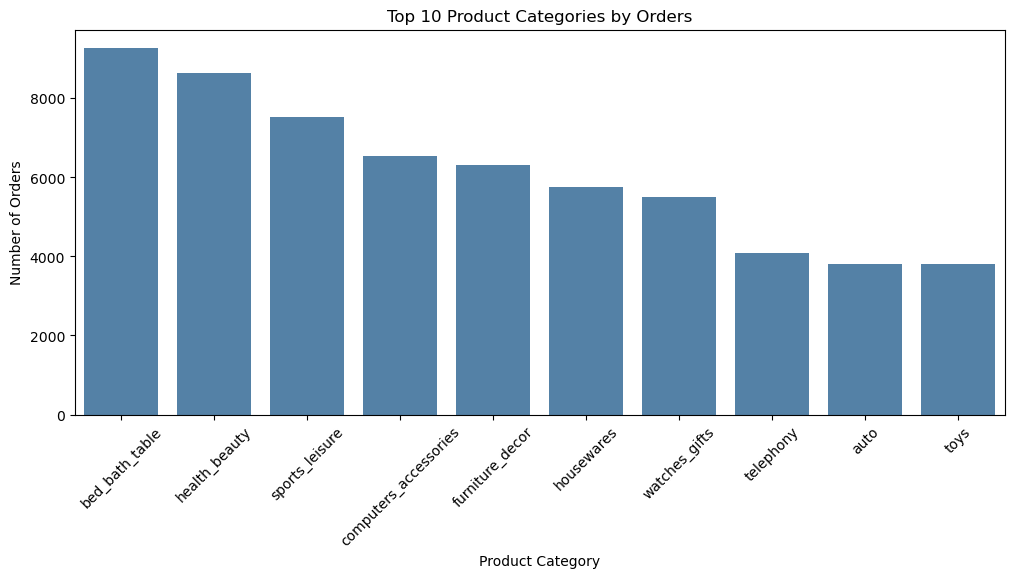

In [32]:
# visualizing top 10 categories by orders

plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_10_categories_by_orders,
    x="category_name",
    y="orders",
    color = "steelblue"
)

plt.title("Top 10 Product Categories by Orders")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [31]:
# average order value by category

category_avg_order_value = (
    delivered_order_items
    .groupby("category_name", as_index=False)
    .agg(
        avg_order_value=("price", "mean"),
        total_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count")
    ).round(2)
)

category_avg_order_value = category_avg_order_value.sort_values("avg_order_value", ascending=False)
category_avg_order_value.head(10)

,category_name,avg_order_value,total_orders,items_sold
14,computers,1098.92,177,199
66,small_appliances_home_oven_and_coffee,638.21,72,73
45,home_appliances_2,467.33,227,231
0,agro_industry_and_commerce,342.55,177,206
56,musical_instruments,283.13,611,651
62,portateis_cozinha_e_preparadores_de_alimentos,280.97,13,14
65,small_appliances,277.74,609,658
34,fixed_telephony,216.92,212,255
19,construction_tools_safety,211.88,159,183
72,watches_gifts,199.04,5495,5859


#### Product and Category Performance Observation

Health and Beauty is the strongest category by product revenue, making it the top revenue contributor in the delivered-order base. However, when categories are ranked by number of delivered orders, Health and Beauty moves to second place, while Bed Bath Table becomes the leading category by order volume. This shows that the highest-revenue category is not always the same as the highest-volume category. When looking at average order value by category, the ranking changes completly: Computers has the highest average order value, above 1,000, but this is based on a much smaller volume of 177 orders and 199 items sold. This suggests that Computers is a high-ticket category, while Health and Beauty and Bed Bath Table are stronger volume/revenue drivers.